In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("../data/processed/air_quality_cleaned.csv")

In [4]:
df.shape

(18265, 14)

In [5]:
df.columns

Index(['Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI'],
      dtype='object')

In [ ]:
#AQI Distribution Analysis

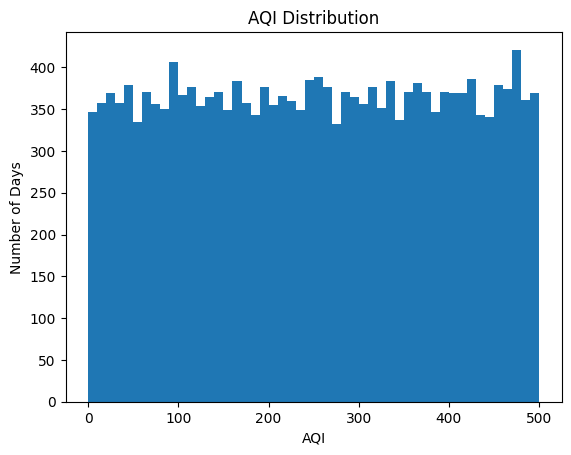

In [5]:
import matplotlib.pyplot as plt

plt.hist(df['AQI'], bins=50)
plt.xlabel("AQI")
plt.ylabel("Number of Days")
plt.title("AQI Distribution")
plt.show()


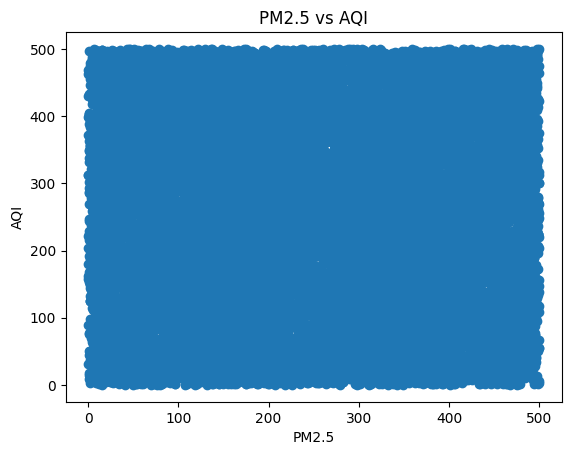

In [42]:
plt.scatter(df['PM2.5'], df['AQI'])
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.title("PM2.5 vs AQI")
plt.show()


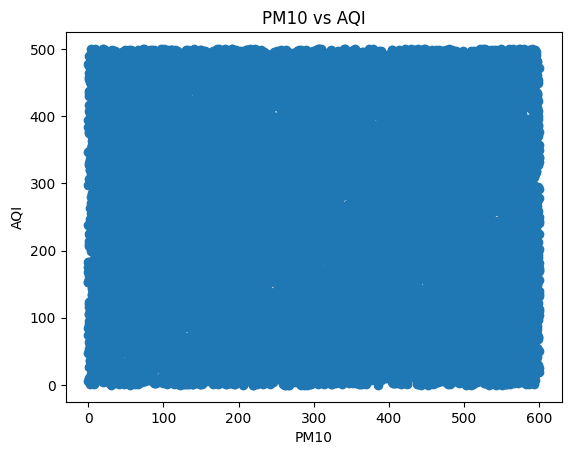

In [43]:
plt.scatter(df['PM10'], df['AQI'])
plt.xlabel("PM10")
plt.ylabel("AQI")
plt.title("PM10 vs AQI")
plt.show()

In [46]:
df.dtypes

Datetime             object
PM2.5               float64
PM10                float64
NO                  float64
NO2                 float64
NOx                 float64
NH3                 float64
CO                  float64
SO2                 float64
O3                  float64
Benzene             float64
Toluene             float64
Xylene              float64
AQI                 float64
Pollution_Level    category
dtype: object

In [47]:
df_numeric = df.select_dtypes(include='number')

In [48]:
df_numeric.corr()['AQI'].sort_values(ascending=False)

AQI        1.000000
NO2        0.011124
Xylene     0.010412
Toluene    0.009428
NH3        0.008079
CO         0.006046
SO2        0.002949
NO         0.001923
PM10       0.001245
PM2.5      0.000655
O3         0.000591
Benzene   -0.001251
NOx       -0.002662
Name: AQI, dtype: float64

In [49]:
def classify_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 200:
        return "Poor"
    elif aqi <= 300:
        return "Very Poor"
    else:
        return "Severe"

In [50]:
df['Risk_Level'] = df['AQI'].apply(classify_aqi)
df[['AQI', 'Risk_Level']].head()

,AQI,Risk_Level
0,204.5,Very Poor
1,60.9,Moderate
2,486.5,Severe
3,174.4,Poor
4,489.7,Severe


In [51]:
df['Risk_Level'].value_counts()

Risk_Level
Severe       7351
Very Poor    3645
Poor         3635
Moderate     1822
Good         1812
Name: count, dtype: int64

In [53]:
df.to_csv("../data/processed/air_quality_with_risk.csv", index=False)